#Notebook: K means
**Autora:** Yadsiri Vazquez\
**Materia:** Clasificación inteligente de datos  

---
##1.1  Fundamentos de la técnica

K-Means es una técnica no supervisada de clustering (agrupamiento) que organiza los datos en k grupos distintos, llamados clústeres, basándose en la similitud (distancia) entre los puntos.

Es importante mencionar que los datos no tienen etiquetas previas.

El algoritmo busca agrupar los puntos de manera que cada clúster sea lo más compacto posible, y los distintos clústeres estén lo más separados entre sí.

Cada grupo se representa mediante un centroide, que es el punto medio del grupo, y su objetivo es minimizar la varianza intra-cluster.

##1.2 Modelo matematico
Dado un conjunto de datos:
X = (X₁,X₂, ... X_n), x_i ∈ ℝ .

y un número de clústeres (k).

El objetivo del algoritmo es minimizar la suma de las distancias cuadradas entre cada punto y el centroide de su grupo asignado. Matemáticamente:

  arg min ***Σ*** de i = 1 hasta k, ***Σ*** de x_j ∈ C_i  ***|| x_j - μ_i ||²***

Donde:

C_i representa el conjunto de puntos asignados al cluster i.

𝜇i es el centroide del cluster i.

Etapas del algoritmo:
1. Inicializar *k* centroides aleatorios.
2. Asignar cada punto al centroide más cercano.
3. Recalcular los centroides.
4. Repetir hasta que los centroides no cambien significativamente.

##1.3 Descripción de la librería, clases y funciones

La implementación de K-Means en Python se realiza mediante la clase KMeans del módulo sklearn.cluster.

**Clase principal:**

from sklearn.cluster import KMeans

**Parámetros relevantes:**

n_clusters: número de clústeres (k).

init: método de inicialización (por defecto "k-means++").

n_init: número de ejecuciones con diferentes centroides iniciales.

max_iter: máximo de iteraciones por ejecución.

random_state: semilla para reproducibilidad.

**Principales métodos:**

- fit(X): entrena el modelo con los datos.

- predict(X): asigna clústeres a nuevos datos.

- fit_predict(X): combina ambos pasos.

- cluster_centers_: obtiene los centroides finales.

- inertia_: devuelve el valor de la función de costo J.

Análisis estadístico del dataset:

                x           y
count  200.000000  200.000000
mean     0.449843    2.708132
std      1.644224    1.589604
min     -3.122407   -0.765892
25%     -1.150634    1.180239
50%      0.970965    2.835179
75%      1.697028    4.096643
max      3.485154    5.474253


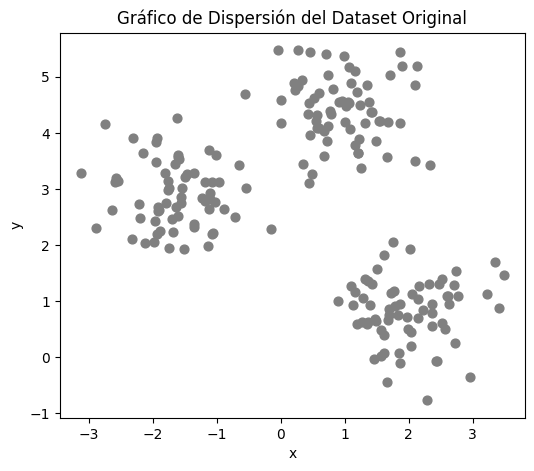

In [7]:
##1.4.1 Preprocesamiento

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Con make_blobs se genera un dataset(3 clusters)
X, y_real = make_blobs(n_samples=200, centers=3, cluster_std=0.6, random_state=0)
df = pd.DataFrame(X, columns=['x', 'y'])

print("Análisis estadístico del dataset:\n")
print(df.describe())

plt.figure(figsize=(6,5))
plt.scatter(df['x'], df['y'], c='gray', s=40)
plt.title('Gráfico de Dispersión del Dataset Original')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

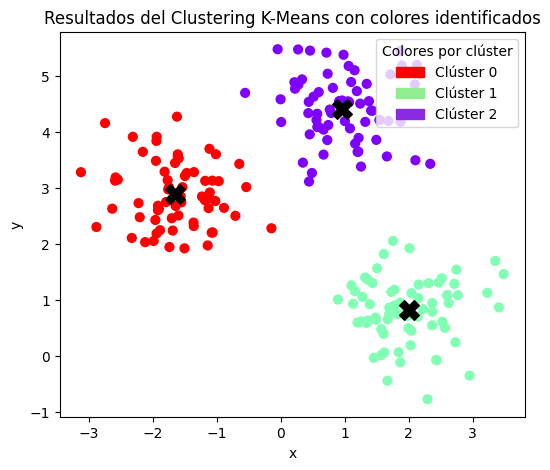

In [8]:
##Entrenamiento del modelo

# Definición de los clusters
k = 3
modelo_kmeans = KMeans(n_clusters=k, random_state=42)
modelo_kmeans.fit(X) #centroides óptimos que minimizan la distancia entre los puntos y su centroide más cercano

#Lo importante, etiquetas y centroides, labels_ asigna un numero de clúster a cada punto ycluster_centers_ devuelve las coordenadas de los centroides.
etiquetas = modelo_kmeans.labels_
centroides = modelo_kmeans.cluster_centers_

plt.figure(figsize=(6,5))
plt.scatter(X[:, 0], X[:, 1], c=etiquetas, cmap='rainbow', s=40)
plt.scatter(centroides[:, 0], centroides[:, 1], c='black', marker='X', s=200, label='Centroides')


leyenda = [
    mpatches.Patch(color='red', label='Clúster 0'),
    mpatches.Patch(color='lightgreen', label='Clúster 1'),
    mpatches.Patch(color='blueviolet', label='Clúster 2')
]
plt.legend(handles=leyenda, title='Colores por clúster', loc='upper right')

plt.title('Resultados del Clustering K-Means con colores identificados')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


In [9]:
## 1.4.2 Prediction
def predecir_clase(modelo, patron):
    #Recibe un modelo entrenado y un patrón. Retorna el numero del clúster al que pertenece el patrón.
    patron = np.array(patron).reshape(1, -1)
    clase_predicha = modelo.predict(patron)
    return clase_predicha[0]

#prediccion
nuevo_patron = [0.5, 2.0]
clase = predecir_clase(modelo_kmeans, nuevo_patron)
print(f"El patrón {nuevo_patron} pertenece al clúster {clase}")


El patrón [0.5, 2.0] pertenece al clúster 1


Matriz de Confusión:
 [[67  0  0]
 [ 0 67  0]
 [ 0  0 66]]


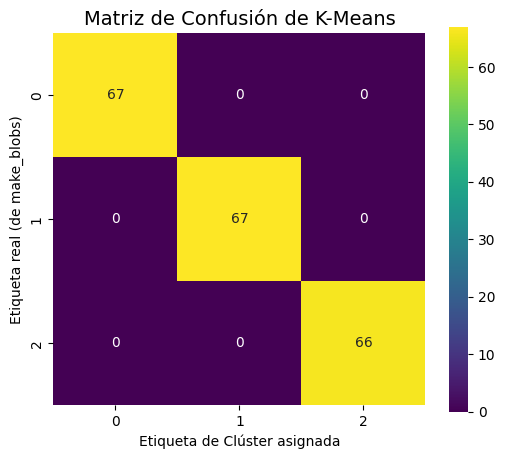


Accuracy del modelo: 100.00%


In [10]:
## Model evaluation

from sklearn.metrics import confusion_matrix, accuracy_score

# Matriz de confusión
matriz_conf = confusion_matrix(y_real, etiquetas)
print("Matriz de Confusión:\n", matriz_conf)

plt.figure(figsize=(6,5))
sns.heatmap(
    matriz_conf,
    annot=True,
    fmt='d',
    cmap='viridis',
    cbar=True,
    square=True
)

plt.title('Matriz de Confusión de K-Means', fontsize=14)
plt.xlabel('Etiqueta de Clúster asignada')
plt.ylabel('Etiqueta real (de make_blobs)')
plt.show()

acc = accuracy_score(y_real, etiquetas)
print(f"\nAccuracy del modelo: {acc*100:.2f}%")


Dato:
- La matriz de confusión muestra cómo los puntos reales se asignaron a los clústeres predichos.
- El Accuracy indica la proporción de aciertos al comparar con las etiquetas reales (si están disponibles).
- Aunque K-Means es no supervisado, esta métrica sirve para validar en datasets simulados.


##2. Interpretación y ejecución

Este notebook puede ejecutarse sin errores tanto en Jupyter como en Google Colab, ya que solo requiere las librerías:  
numpy, `matplotlib, y scikit-learn.

Para ejecutarlo en Colab:
1. Abre [https://colab.research.google.com](https://colab.research.google.com)
2. Sube este notebook o crea uno nuevo.
3. Ejecuta las celdas secuencialmente.

##3- Bibliografía
- Aviña Méndez, J. A. (2024). *Guía de Estudio: Clasificador k-Means. Repositorio: [https://github.com/joseavinatecmm/IDC](https://github.com/joseavinatecmm/IDC)
- Scikit-learn Developers (2024). *Documentation: sklearn.cluster.KMeans.*
  https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
